# Lab 1 

## A Little Statistics

In [1]:
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
plt.rcParams["figure.figsize"] = (15,10)

#### 1.b) Try integrating the standard normal distribution

In [2]:
# Function to determine numerical position on standard normal curve from mathisfun reading
def x_pos(z, mean, scale):
    x = z*scale + mean
    return x

In [3]:
# Evaluating integrals with loc(mean) = 0 and various scales(stddev)
#Finds position on standard normal for a zscale of -3.5
x1 = x_pos(-3.5, 0, 1)
print(f'Integral Value: {stats.norm.cdf(x1, loc = 0, scale = 1):.5f}; Z Table: 0.00023 ')
# Position of zscale of -1.25
x2 = x_pos(-1.25, 0, 1)
print(f'Integral Value: {stats.norm.cdf(x2, loc = 0,scale =1):.5f}; Z Table: 0.10565')

Integral Value: 0.00023; Z Table: 0.00023 
Integral Value: 0.10565; Z Table: 0.10565


#### 1.c) Now more often than not, we actually want to do the inverse: for a given probability determine the associated 'sigma' value in python.

In [4]:
# +/- 1 Sigma
print(f'A probability of 15.9% returns z-score:{stats.norm.ppf(0.159, loc = 0, scale = 1):.4f}')
print(f'A probability of 84.1% returns z-score:{stats.norm.ppf(0.841, loc = 0, scale = 1):.4f}')
# +/- 2 Sigma
print(f'A probability of 2.3% returns z-score:{stats.norm.ppf(0.023, loc = 0, scale = 1):.4f}')
print(f'A probability of 97.7% returns z-score:{stats.norm.ppf(0.977, loc = 0, scale = 1):.4f}')
# +/- 5 sigma
print(f'A probability of 0.00006% returns z-score:{stats.norm.ppf(0.0000006, loc = 0, scale = 1):.4f}')
print(f'A probability of 99.99994% returns z-score:{stats.norm.ppf(0.9999994, loc = 0, scale = 1):.4f}')

A probability of 15.9% returns z-score:-0.9986
A probability of 84.1% returns z-score:0.9986
A probability of 2.3% returns z-score:-1.9954
A probability of 97.7% returns z-score:1.9954
A probability of 0.00006% returns z-score:-4.8556
A probability of 99.99994% returns z-score:4.8556


#### 1.d) Why do negative values sometimes appear?

Negative sigma values are returned from the norm.ppf function when the probability input is less than 50%. Since the function integrates from $- \infty$ to the chosen percent value along the standard normal distribution, negative sigmas occur on the left side of the mean and positive on the right corresponding to smaller or larger percentages of the curve being integrated over. 

### 2) Rayleigh Distributions

In [5]:
# Sample 100k datapoints in the Rayleigh Distribution with loc = 4, scale = 2
datapoints = stats.rayleigh.rvs(size = 100000, loc = 4, scale = 2)

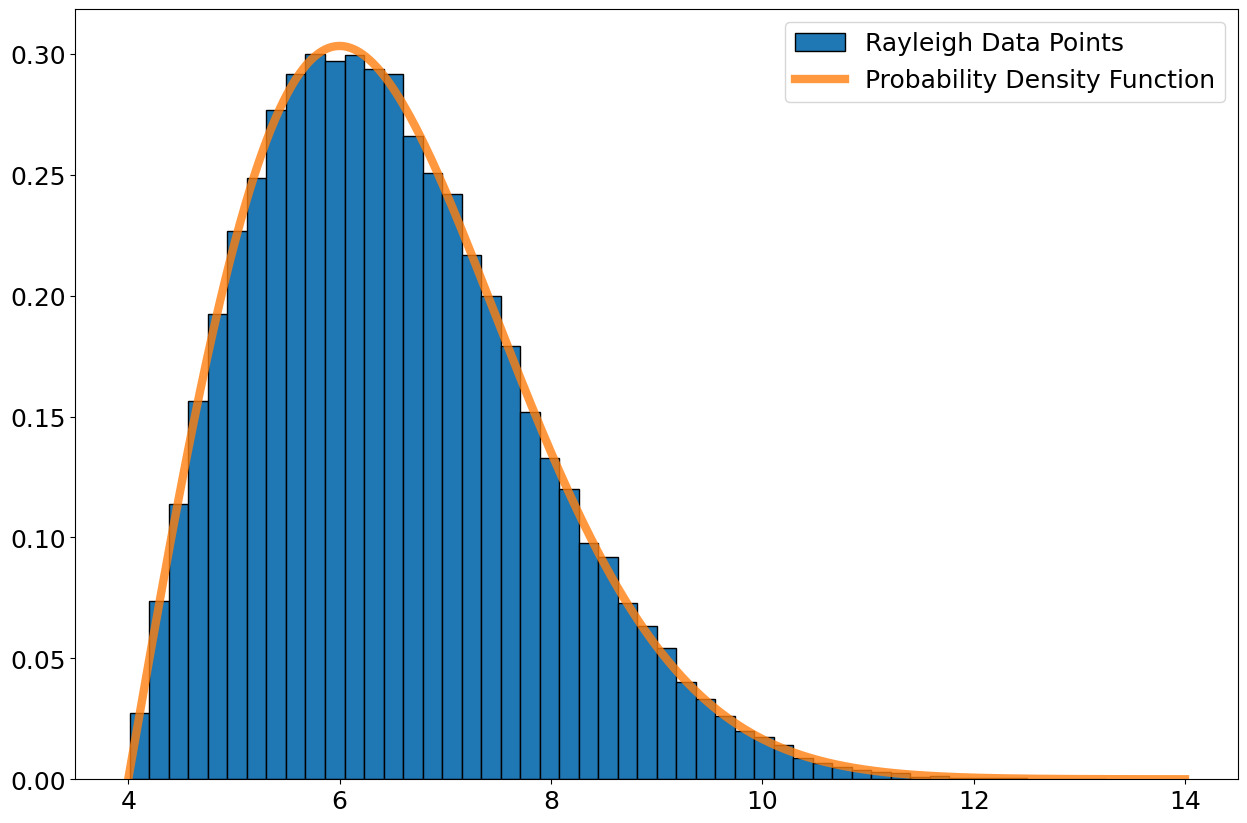

In [6]:
# Setting up plot of the random datapoints overplotted with the pdf
fig, ax = plt.subplots()
ax.hist(datapoints, 50, density = True, edgecolor = 'black', label = 'Rayleigh Data Points')
# Select 1000 values of x for the pdf to create smooth curve
x = np.linspace(4,14, 1000)
ax.plot(x, stats.rayleigh.pdf(x, loc = 4, scale = 2), linewidth = 6, alpha = 0.8, label = 'Probability Density Function')
plt.legend(loc = 0, fontsize = 18)
plt.tick_params(labelsize = 18)
plt.show()

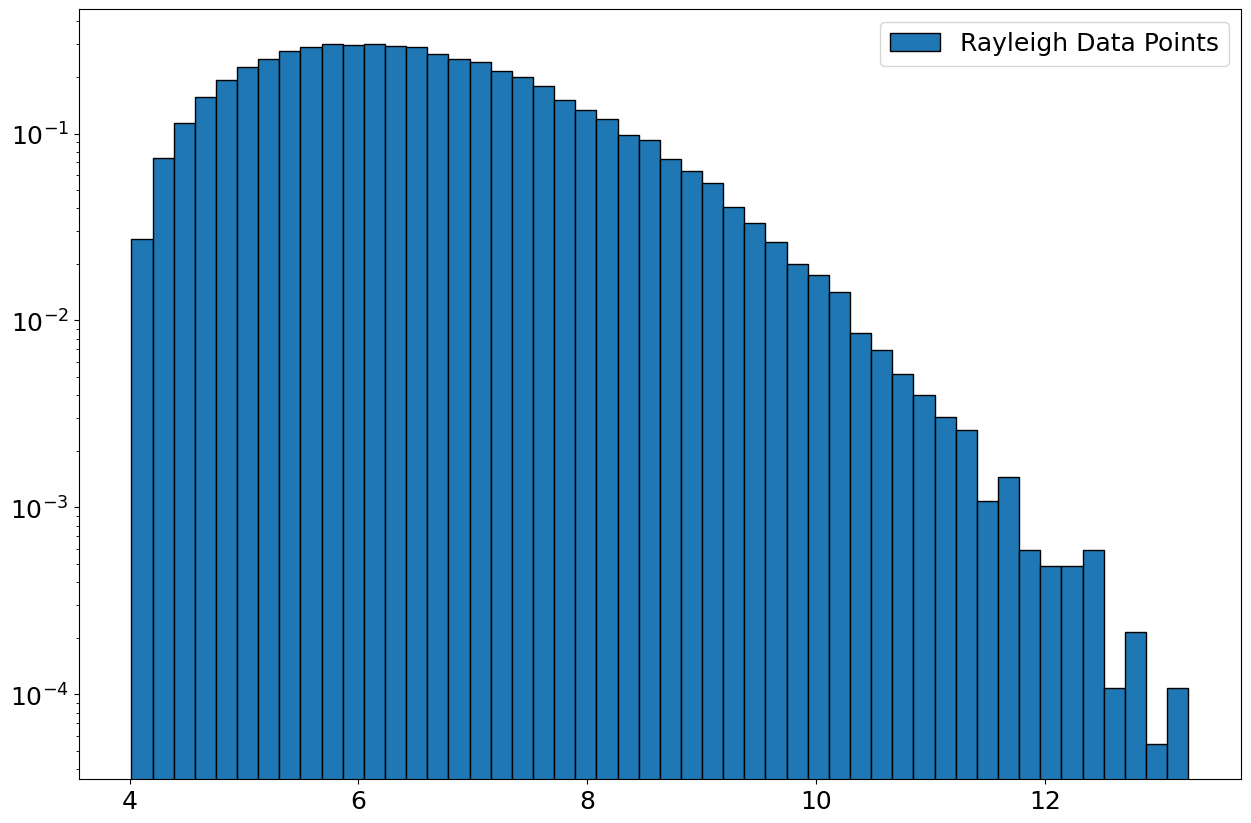

In [7]:
# Sets up plot of datapoints on semilog scale
fig, ax = plt.subplots()
ax.hist(datapoints, 50, density = True, edgecolor = 'black', label = 'Rayleigh Data Points')
plt.tick_params(labelsize = 18)
plt.yscale('log')
# Select 1000 values of x for the pdf to create smooth curve
plt.legend(loc = 0, fontsize = 18)
plt.show()

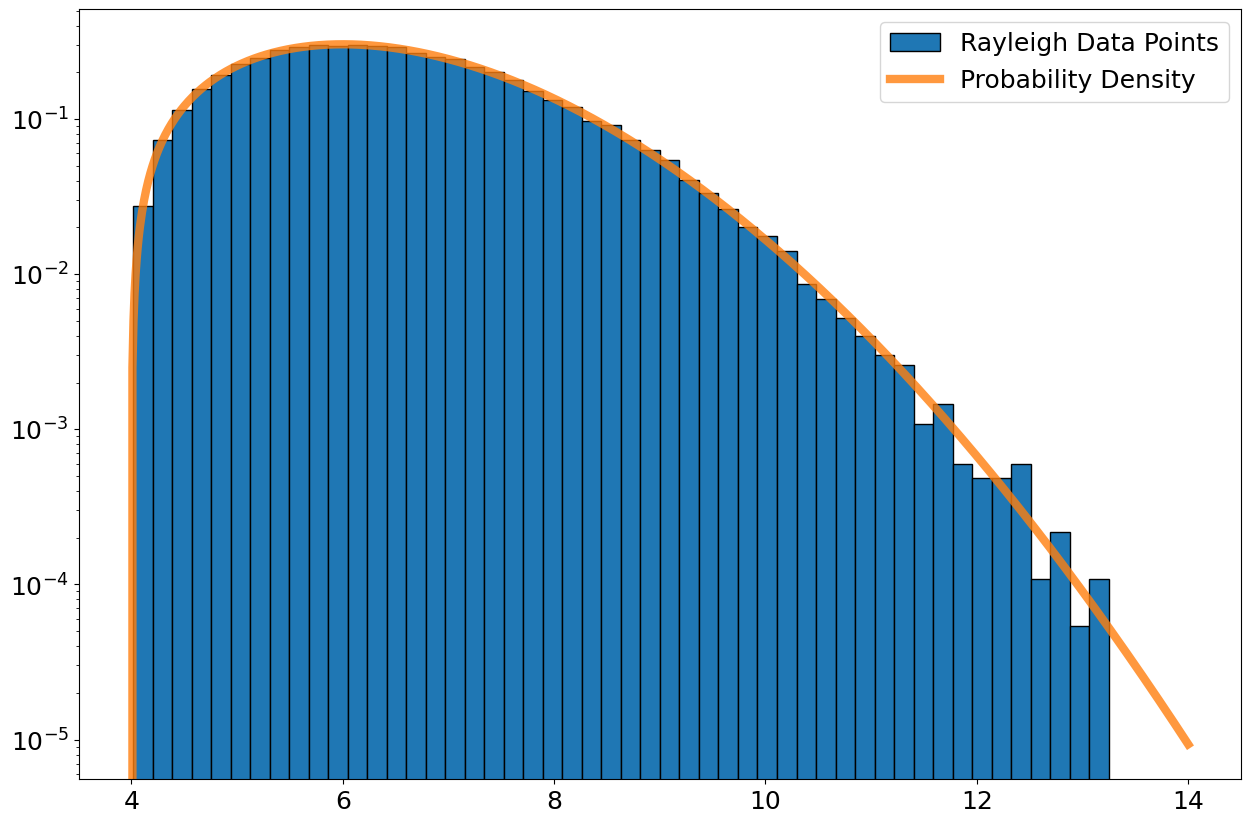

In [8]:
# Reimplements the pdf function in semi-log scale
fig, ax = plt.subplots()
ax.hist(datapoints, 50, density = True, edgecolor = 'black', label = 'Rayleigh Data Points')
plt.tick_params(labelsize = 18)
plt.yscale('log')
# Select 1000 values of x for the pdf to create smooth curve
x = np.linspace(4,14, 1000)
ax.plot(x, stats.rayleigh.pdf(x, loc = 4, scale = 2), linewidth = 6, alpha = 0.8, label = 'Probability Density')
plt.legend(loc = 0, fontsize = 18)
plt.show()

### 3. Imagine that your signal-free data follows the distribution you have chosen; and you have a measurement for which you need to determine the 'sigma'

#### a) What is the hypothetical value?

9.2

#### b) Clearly state the question in words?

As per lecture, what is the probability that background noise following a Rayleigh distribution produces a signal that is equal to or higher than the hypothetical value?

#### c) Convert the question to a mathematical integral

$$P(x) = \int_0^{9.2} 1- e^{\frac{-x^2}{2\sigma^2}} $$

#### d) Calculate the probability the background produced the signal

In [9]:
# Calculates the probability the distribution produces a signal less than 9.2
p_less = stats.rayleigh.cdf(9.2, loc = 4, scale = 2)
# Converts to probability of background producing a larger or equal signal since cdf integrates from left to right
p_greater = 1 - p_less
print(f'Probability the background produces the signal: {p_greater:.3f}')

Probability the background produces the signal: 0.034


#### e) Convert probability to equivalent sigma

In [10]:
sigma = stats.norm.ppf(p_greater, loc = 0, scale = 1)
print(f"""The equivalent sigma on the standard normal distribution is: {sigma:.2f} which shows that it is unlikely 
for the background noise to produce a signal greater or equal to 9.2""")

The equivalent sigma on the standard normal distribution is: -1.82 which shows that it is unlikely 
for the background noise to produce a signal greater or equal to 9.2


### 4. Explore different hypotherical values

In [11]:
def rayleigh_sigma(value, mean = 4, sigma = 2):
    prob = 1 - stats.rayleigh.cdf(value, loc = mean, scale = sigma)
    sigma = stats.norm.ppf(prob)

    return prob, sigma

In [18]:
# Hypothetical value 4.5
p1, s1 = rayleigh_sigma(4.2)
print(f'Value: 4.5; Probability: {p1:.4f}; Sigma: {s1:.4f}')

# Hypothetical Value 7.3
p2, s2 = rayleigh_sigma(7.3)
print(f'Value: 7.3; Probability: {p2:.4f}; Sigma: {s2:.4f}')

# Hypothetical Value 12.0
p3, s3 = rayleigh_sigma(12)
print(f'Value: 12; Probability: {p3:.4f}; Sigma: {s3:.4f}')

# Hypothetical Value 6.4
p4, s4 = rayleigh_sigma(6.4)
print(f'Value: 6.4; Probability: {p4:.4f}; Sigma: {s4:.4f}')

Value: 4.5; Probability: 0.9950; Sigma: 2.5767
Value: 7.3; Probability: 0.2563; Sigma: -0.6547
Value: 12; Probability: 0.0003; Sigma: -3.4012
Value: 6.4; Probability: 0.4868; Sigma: -0.0332


The pattern I see when testing multiple hypothetical values is that the probability of each value being produced by the background decreases as the value grows higher. The corresponding sigma value is negative when the probabilty of being produced by the background is less than 50% and positive when the probability is greater than 50% indicating that the measurement is likely to be noise. 